# Titanic analysis without Agent Skills

Agent Skillsを使用しない比較用ノートブックです。データ確認、前処理、モデル学習、提出CSV作成までを通常のPythonコードで行います。

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print('train:', train.shape)
print('test :', test.shape)
train.head()

train: (891, 12)
test : (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


,missing
Cabin,687
Age,177
Embarked,2
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
SibSp,0
Parch,0


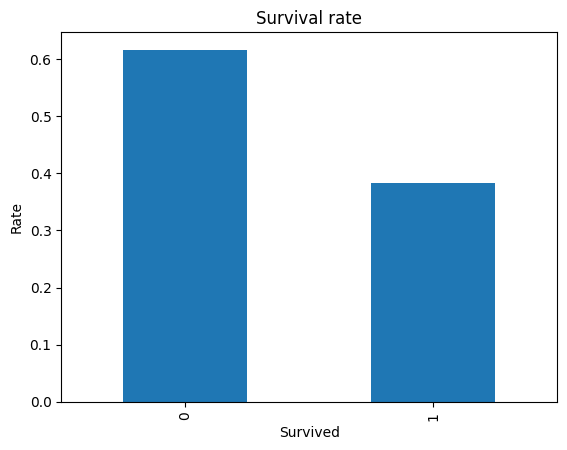

In [8]:
print(train.info())
display(train.describe(include='all').T)
display(train.isna().sum().sort_values(ascending=False).to_frame('missing'))

train['Survived'].value_counts(normalize=True).sort_index().plot(
    kind='bar', title='Survival rate'
)
plt.xlabel('Survived')
plt.ylabel('Rate')
plt.show()

In [9]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
combined = pd.concat(
    [train[features], test[features]],
    axis=0,
    ignore_index=True,
)
combined['Age'] = combined['Age'].fillna(combined['Age'].median())
combined['Fare'] = combined['Fare'].fillna(combined['Fare'].median())
combined['Embarked'] = combined['Embarked'].fillna(combined['Embarked'].mode()[0])
combined = pd.get_dummies(combined, columns=['Sex', 'Embarked'], drop_first=True)

X = combined.iloc[:len(train)].copy()
X_test = combined.iloc[len(train):].copy()
y = train['Survived']

print(X.shape, X_test.shape)
X.head()

(891, 8) (418, 8)


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [10]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)
valid_predictions = model.predict(X_valid)

print('Validation accuracy:', round(accuracy_score(y_valid, valid_predictions), 4))
print(classification_report(y_valid, valid_predictions))

Validation accuracy: 0.8045
              precision    recall  f1-score   support

           0       0.79      0.93      0.85       110
           1       0.84      0.61      0.71        69

    accuracy                           0.80       179
   macro avg       0.82      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179



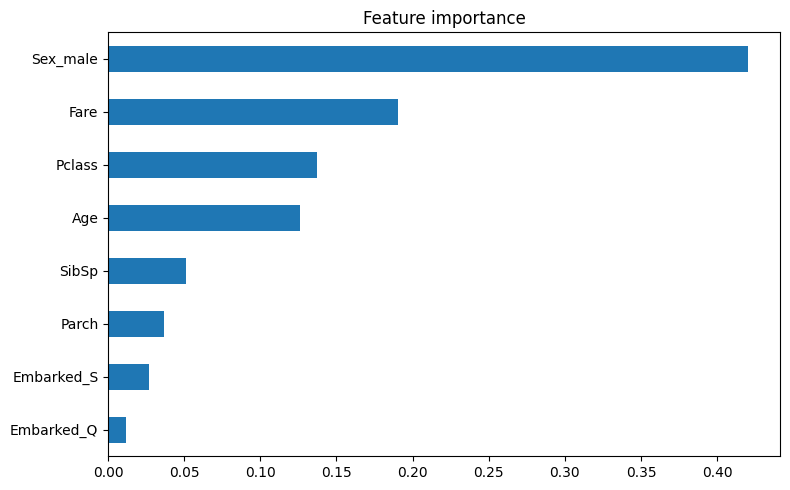

In [11]:
importance = pd.Series(
    model.feature_importances_, index=X.columns
).sort_values(ascending=True)
importance.plot(kind='barh', figsize=(8, 5), title='Feature importance')
plt.tight_layout()
plt.show()

In [12]:
model.fit(X, y)
test_predictions = model.predict(X_test).astype(int)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_predictions,
})
submission.to_csv('submission_no_skills.csv', index=False)
print('saved: submission_no_skills.csv')
print('rows:', len(submission))
display(submission.head())

saved: submission_no_skills.csv
rows: 418


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
